<a href="https://colab.research.google.com/github/emiliomercuri/EnvHydrology2026/blob/main/Aulas/Aula08-agua_precipitavel%2Bprec_media/Exemplo_Curva_Chave.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade para cálculo da Curva Chave

Encontre a **curva de descarga** para os dados a seguir:

| Gage <br> height (ft) | Discharge <br> (cfs) |
| :---: | :---: |
|  |  |
| 1.5 | 20 |
| 2.0 | 131 |
| 2.5 | 307 |
| 3.0 | 530 |
| 3.5 | 808 |
| 4.0 | 1,130 |
| 4.5 | 1,498 |
| 5.0 | 1,912 |
| 6.0 | 2,856 |
| 7.0 | 3,961 |
| 8.0 | 5,212 |
| 9.0 | 6,561 |
| 10.0 | 8,000 |
| 11.0 | 9,588 |
| 12.0 | 11,300 |
| 13.0 | 13,100 |
| 14.0 | 15,000 |
| 15.0 | 17,010 |
| 16.0 | 19,110 |
| 17.0 | 21,340 |
| 18.0 | 23,920 |
| 19.0 | 26,230 |
| 20.0 | 28,610 |

## Funções típicas para a curva chave

Sendo $Q$ a vazão e $H$ o nível do rio, temos:

* Potência: $Q(H)=a(H-h_0)^{n}$
* Linear: $Q(H)=a_0+a_1 H$
* Parabólica:$Q(H)=a_0+a_1 H+a_2 H^{2}$
* Cúbica: $Q(H)=a_0+a_1 H+a_2 H^{2} +a_3 H^{3}$

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
dados = pd.read_csv('https://www.dropbox.com/scl/fi/nnwel7olegrn97yfv72qf/tabela_curva_chave.csv?rlkey=pylim0nemorakn3d9jd9lhze9&dl=1')
dados

,Gage_height(ft),Discharge(cfs)
0,1.5,20
1,2.0,131
2,2.5,307
3,3.0,530
4,3.5,808
5,4.0,1130
6,4.5,1498
7,5.0,1912
8,6.0,2856
9,7.0,3961


In [ ]:
dados.dtypes

,0
Gage_height(ft),float64
Discharge(cfs),int64


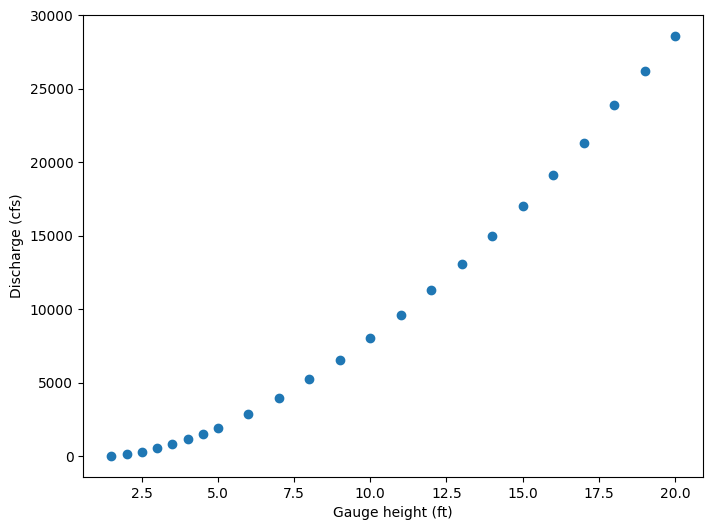

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(dados['Gage_height(ft)'],dados['Discharge(cfs)'])
plt.xlabel('Gauge height (ft)')
plt.ylabel('Discharge (cfs)')
plt.show()

## Vamos adicionar uma aleatoriedade nesses dados

In [ ]:
varia_x = np.random.uniform(low=-1.0, high=1.0, size=len(dados))
varia_y = np.random.uniform(low=-1.0, high=1.0, size=len(dados))
varia_x,varia_y

(array([ 0.42626708,  0.2627446 , -0.14773723, -0.6978554 , -0.28103751,
         0.22056074, -0.85748175,  0.06280384,  0.61955523, -0.27409929,
         0.73872225,  0.79345639,  0.05608072,  0.15822452,  0.4586294 ,
         0.01225744,  0.44180799, -0.56080258, -0.8384312 ,  0.74615696,
        -0.85411959, -0.14760201,  0.65092217]),
 array([-0.19344435, -0.06692741, -0.58101922, -0.96372026, -0.26713182,
         0.76714986, -0.20411608,  0.52146755, -0.27920809, -0.51115025,
         0.04545209,  0.50289332, -0.76348197, -0.42458263,  0.95978293,
        -0.72572096,  0.27622546, -0.51208797, -0.28982696,  0.1303622 ,
         0.67650588, -0.60856613,  0.51528081]))

In [ ]:
dados['Gage_height_var(ft)'] = dados['Gage_height(ft)'] + dados['Gage_height(ft)']*varia_x/5
dados['Discharge_var(cfs)'] = dados['Discharge(cfs)'] + dados['Discharge(cfs)']*varia_y/5

In [ ]:
dados

,Gage_height(ft),Discharge(cfs),Gage_height_var(ft),Discharge_var(cfs)
0,1.5,20,1.627880,19.226223
1,2.0,131,2.105098,129.246502
2,2.5,307,2.426131,271.325420
3,3.0,530,2.581287,427.845653
4,3.5,808,3.303274,764.831498
5,4.0,1130,4.176449,1303.375867
6,4.5,1498,3.728266,1436.846823
7,5.0,1912,5.062804,2111.409190
8,6.0,2856,6.743466,2696.516340
9,7.0,3961,6.616261,3556.066771


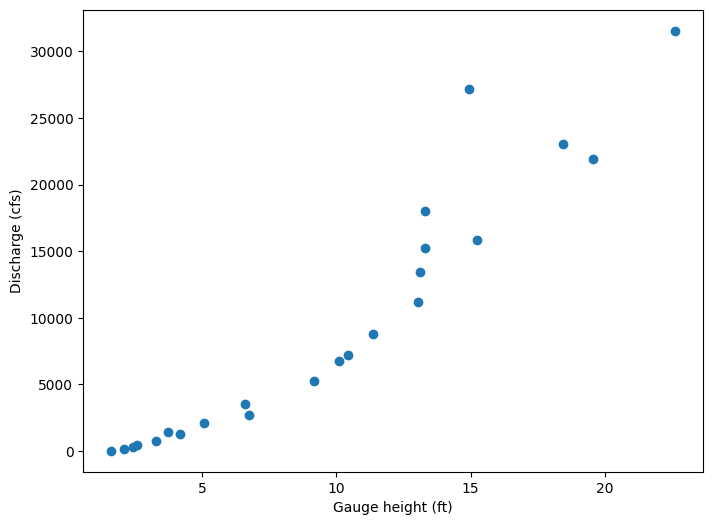

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(dados['Gage_height_var(ft)'],dados['Discharge_var(cfs)'])
plt.xlabel('Gauge height (ft)')
plt.ylabel('Discharge (cfs)')
plt.show()

In [ ]:
def potencia(H,a,h0,n):
  return a*(H-h0)**n

In [ ]:
xdata = dados['Gage_height(ft)'].values
ydata = dados['Discharge(cfs)'].values
popt0, pcov0 = curve_fit(potencia, xdata, ydata)
popt0

array([211.48622006,   1.26066776,   1.67541678])

O ajuste do método dos Mínimos Quadrados (Scipy) forneceu a seguinte equação, com as constantes: $a = 211.48622006$, $b = 1.26066776$ e $c = 1.67541678$.

$$
Q(H)=211.49 (H-1.26)^{1.67}
$$

In [ ]:
xdata = dados['Gage_height_var(ft)'].values
ydata = dados['Discharge_var(cfs)'].values
popt, pcov = curve_fit(potencia, xdata, ydata)
popt

<ipython-input-25-c77d45815046>:2: RuntimeWarning: invalid value encountered in power
  return a*(H-h0)**n


array([377.66960476,   1.62786741,   1.46186361])

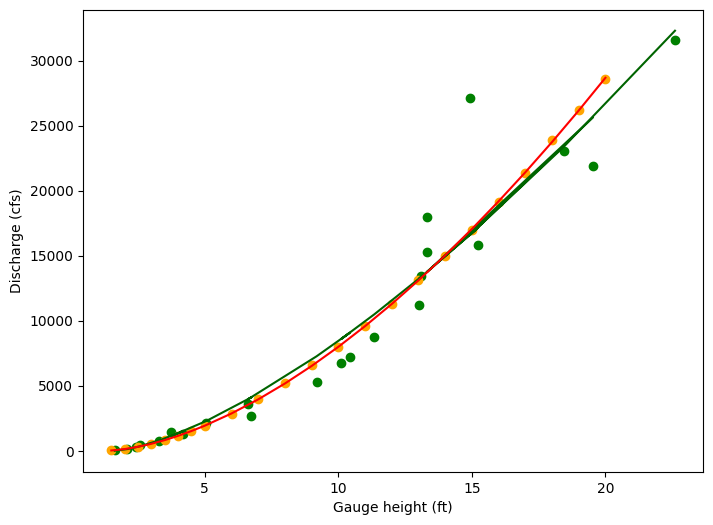

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(dados['Gage_height_var(ft)'],dados['Discharge_var(cfs)'],color='green')
plt.scatter(dados['Gage_height(ft)'],dados['Discharge(cfs)'],color='orange')
plt.plot(dados['Gage_height_var(ft)'],potencia(dados['Gage_height_var(ft)'],popt[0],popt[1],popt[2]),color='darkgreen')
plt.plot(dados['Gage_height(ft)'],potencia(dados['Gage_height(ft)'],popt0[0],popt0[1],popt0[2]),color='red')
plt.xlabel('Gauge height (ft)')
plt.ylabel('Discharge (cfs)')
plt.show()

In [ ]:
dados_var = dados[['Gage_height_var(ft)','Discharge_var(cfs)']]

In [ ]:
dados_var

,Gage_height_var(ft),Discharge_var(cfs)
0,1.775529,17.921584
1,2.111949,152.838589
2,2.345843,316.243543
3,3.278575,539.440351
4,3.354171,926.995426
5,3.783648,1163.537512
6,4.577131,1767.736294
7,5.076309,1680.351834
8,6.797520,2295.962034
9,6.054267,3420.597524


In [ ]:
dados_var.to_csv('dados_Q+H_ex_curva-chave.csv')